In [20]:
import numpy as np
import time
import matplotlib.pyplot as plt

In [16]:
def fast_mmd(X1, X2, sigma=1.0, L=1000):
    m,d = X1.shape
    n,vide = X2.shape

    k_0 = 1.0

    W = np.random.normal(loc=0.0, scale=1.0/sigma, size=(d,L)) #pour le noyau gaussien on tire selon une normale

    proj_X1 = np.dot(X1, W)
    proj_X2 = np.dot(X2, W)
    z_X1 = (k_0/np.sqrt(L))*np.concatenate([np.cos(proj_X1), np.sin(proj_X1)], axis=1)
    z_X2 = (k_0/np.sqrt(L))*np.concatenate([np.cos(proj_X2), np.sin(proj_X2)], axis=1)
    z1 = np.mean(z_X1, axis=0)
    z2 = np.mean(z_X2, axis=0)


    mmd_b2 = np.sum((z1- z2)**2)


    norme_z1_sq = np.sum(z1**2)
    norme_z2_sq = np.sum(z2**2)
    correction = ((m+n-2)/((m-1)*(n-1)))*k_0
    mmd_u2 = mmd_b2+(1/(m-1))*norme_z1_sq+(1/(n-1))*norme_z2_sq- correction

    return(mmd_b2, mmd_u2)


In [17]:
def rbf_kernel_matrix(X, Y, sigma=1.0): #gemini pour une implémentation rapide du noyau

    X_sq = np.sum(X**2, axis=1)[:, np.newaxis]
    Y_sq = np.sum(Y**2, axis=1)[np.newaxis, :]

    sq_dists = X_sq + Y_sq - 2 * np.dot(X, Y.T)
    sq_dists = np.clip(sq_dists, 0, None)
    return np.exp(-sq_dists / (2 * sigma**2))

def standard_mmd(X1, X2, sigma=1.0):
    m = X1.shape[0]
    n = X2.shape[0]

    K_XX = rbf_kernel_matrix(X1, X1, sigma)
    K_YY = rbf_kernel_matrix(X2, X2, sigma)
    K_XY = rbf_kernel_matrix(X1, X2, sigma)

    mmd_b2 = np.mean(K_XX) +np.mean(K_YY)-2*np.mean(K_XY)

    sum_XX_nodiag = np.sum(K_XX)-m
    sum_YY_nodiag = np.sum(K_YY)-n
    terme_1 = sum_XX_nodiag/(m*(m-1))
    terme_2 = sum_YY_nodiag/(n*(n-1))
    terme_3 = 2*np.mean(K_XY)
    mmd_u2 = terme_1+terme_2-terme_3

    return(mmd_b2, mmd_u2)

## On souhaite maintenant comparer les deux fonctions pour voir le gain obtenu grace aux RFFs

In [35]:
taille_échantillon = [1000,3000,6000,10000,15000,20000,25000,30000]
temps_standard = []
temps_fast = []

mmdu_standard = []
mmdu_fast = []

mmdb_standard = []
mmdb_fast = []

for taille in taille_échantillon:

    X1 = np.random.randn(taille, 10)
    X2 = np.random.randn(taille, 10) + 0.5

    start = time.perf_counter()
    b, u = fast_mmd(X1, X2, sigma=1.0, L=1024)
    end = time.perf_counter()

    temps_fast.append(end-start)
    mmdb_fast.append(b)
    mmdu_fast.append(u)

    start = time.perf_counter()
    b, u = standard_mmd(X1, X2, sigma=1.0)
    end = time.perf_counter()

    temps_standard.append(end-start)
    mmdb_standard.append(b)
    mmdu_standard.append(u)

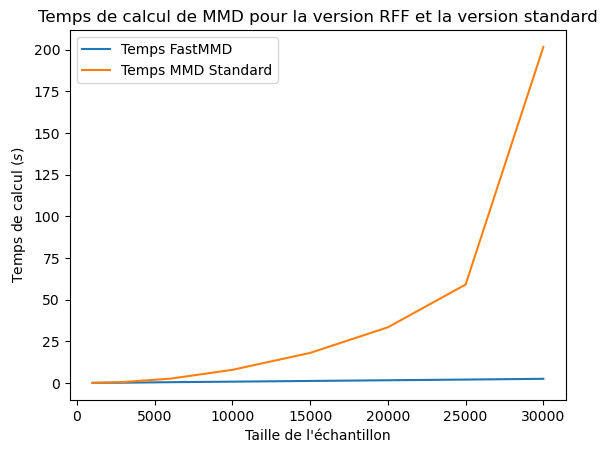

In [36]:
#affichage

plt.figure()
plt.clf()
plt.plot(taille_échantillon,temps_fast, label="Temps FastMMD")
plt.plot(taille_échantillon,temps_standard, label="Temps MMD Standard")
plt.title("Temps de calcul de MMD pour la version RFF et la version standard")
plt.xlabel("Taille de l'échantillon")
plt.ylabel("Temps de calcul ($s$)")
plt.legend(loc="best")

Text(0, 0.5, 'Erreur relative ')

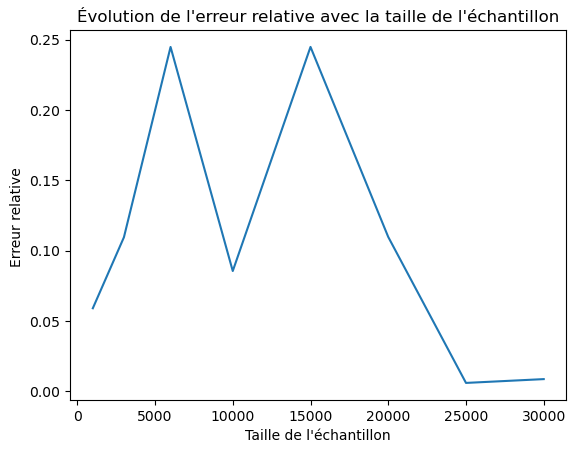

In [37]:
diff_MMDu =np.absolute(np.array(mmdu_standard)-np.array(mmdu_fast))/np.absolute(np.array(mmdu_standard))
plt.figure()
plt.clf()
plt.plot(taille_échantillon,diff_MMDu)
plt.title("Évolution de l'erreur relative avec la taille de l'échantillon")
plt.xlabel("Taille de l'échantillon")
plt.ylabel("Erreur relative ")

Text(0, 0.5, 'Erreur relative ')

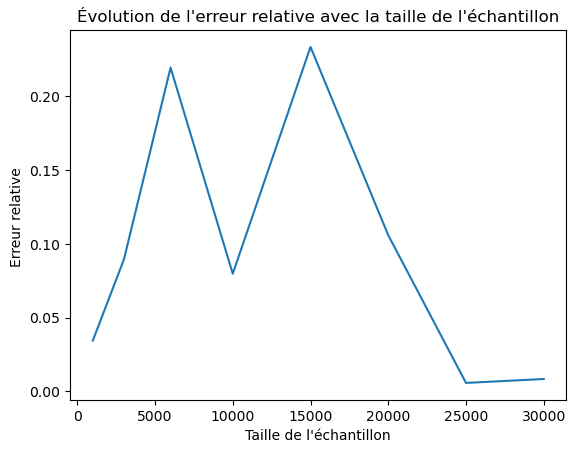

In [38]:
diff_MMDb =np.absolute(np.array(mmdb_standard)-np.array(mmdb_fast))/np.absolute(np.array(mmdb_standard))
plt.figure()
plt.clf()
plt.plot(taille_échantillon,diff_MMDb)
plt.title("Évolution de l'erreur relative avec la taille de l'échantillon")
plt.xlabel("Taille de l'échantillon")
plt.ylabel("Erreur relative ")